In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import EditedNearestNeighbours


from lightgbm import LGBMClassifier

from sklearn.model_selection import GridSearchCV

import sys
from pathlib import Path


# Get project root
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

%load_ext autoreload
%autoreload 2

import utils.evaluation as evaluate
import utils.visualization_utils as visualize

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR    = Path("../data")
OUTPUT_DIR  = Path("../data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### 01. Load Data

In [2]:
train_df = pd.read_parquet(DATA_DIR / "train_features.parquet", engine="fastparquet")
holdout_df = pd.read_parquet(DATA_DIR / "holdout_features.parquet", engine="fastparquet")
oot_df = pd.read_parquet(DATA_DIR / "oot_features.parquet", engine="fastparquet")

print("Train shape   :", train_df.shape)
print("Holdout shape :", holdout_df.shape)
print("OOT shape     :", oot_df.shape)

Train shape   : (1341934, 32)
Holdout shape : (210771, 32)
OOT shape     : (201450, 32)


### 02. Prepare Data For Training

In [3]:
COLS_TO_DROP = ["TX_FRAUD", "TX_FRAUD_SCENARIO", 
                "day_of_week", "nb_terminals", "mean_nb_tx_per_day",
                "TX_DATETIME"]
TARGET = "TX_FRAUD"

In [4]:
# ==========================
# Training Set
# ==========================
X_train = train_df.drop(columns=COLS_TO_DROP)
y_train = train_df[TARGET]

# ==========================
# Holdout (Validation) Set
# ==========================
X_holdout = holdout_df.drop(columns=COLS_TO_DROP)
y_holdout = holdout_df[TARGET]

# ==========================
# Out-of-Time (Final Test) Set
# ==========================
X_oot = oot_df.drop(columns=COLS_TO_DROP)
y_oot = oot_df[TARGET]

# ==========================
# Check shapes
# ==========================
print("Train   :", X_train.shape, y_train.shape)
print("Holdout :", X_holdout.shape, y_holdout.shape)
print("OOT     :", X_oot.shape, y_oot.shape)

Train   : (1341934, 26) (1341934,)
Holdout : (210771, 26) (210771,)
OOT     : (201450, 26) (201450,)


### 04. Apply Transformation Preprocessor

In [5]:
# define preprocess pipeline
cat_cols = X_train.select_dtypes(include=["object"]).columns
num_cols = X_train.select_dtypes(exclude=["object"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols)
    ]
)

### 05. Training on Balanced Data

In [6]:
rus = RandomUnderSampler(
    sampling_strategy=0.2,
    random_state=42
)

# Fit preprocessing
X_train_preprocessed = preprocess.fit_transform(X_train)

# Apply undersampling
X_under, y_under = rus.fit_resample(
    X_train_preprocessed,
    y_train
)

In [7]:
print(f"Original samples      : {len(y_train):,}")
print(f"After undersampling   : {len(y_under):,}")

print("\nOriginal distribution")
print(y_train.value_counts())

print("\nAfter undersampling")
print(y_under.value_counts())

class_counts = y_under.value_counts()

normal = class_counts[0]
fraud = class_counts[1]

print(f"\nNormal transactions : {normal:,}")
print(f"Fraud transactions  : {fraud:,}")

print(f"\nFraud : Normal = 1 : {normal/fraud:.2f}")
print(f"Minority ratio = {fraud/normal:.2f}")

Original samples      : 1,341,934
After undersampling   : 66,048

Original distribution
TX_FRAUD
0    1330926
1      11008
Name: count, dtype: int64

After undersampling
TX_FRAUD
0    55040
1    11008
Name: count, dtype: int64

Normal transactions : 55,040
Fraud transactions  : 11,008

Fraud : Normal = 1 : 5.00
Minority ratio = 0.20


In [8]:
# models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "LDA": LinearDiscriminantAnalysis(),

    "LightGBM": LGBMClassifier(
        objective="binary",
        random_state=42
    )
}

Logistic Regression

Best threshold (by f1): 0.92
Precision: 0.881
Recall:    0.801
F1:        0.839

==================== Logistic Regression (UnderSampling) ====================
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    208887
       Fraud       0.88      0.80      0.84      1884

    accuracy                           1.00    210771
   macro avg       0.94      0.90      0.92    210771
weighted avg       1.00      1.00      1.00    210771

ROC-AUC:  0.9719
PR-AUC:   0.8757


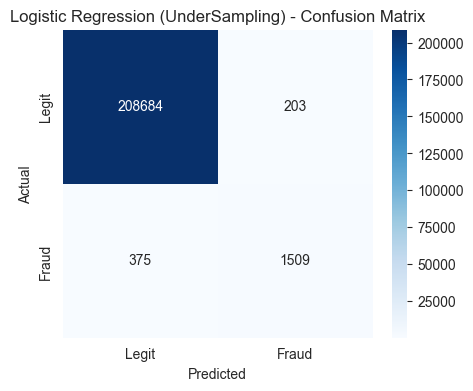

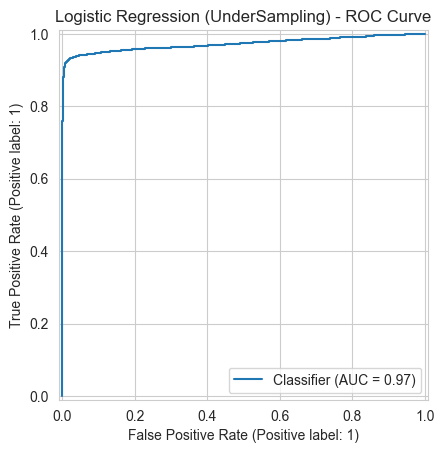

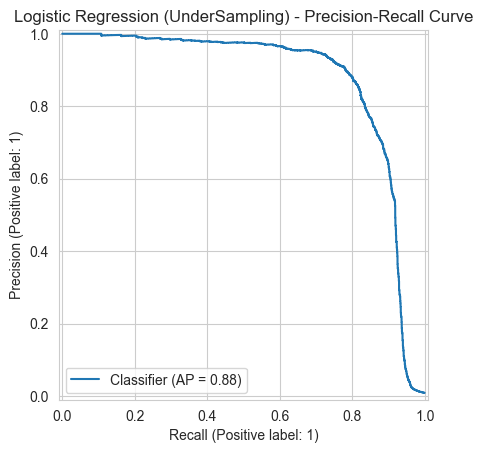

LDA

Best threshold (by f1): 0.86
Precision: 0.878
Recall:    0.781
F1:        0.826

==================== LDA (UnderSampling) ====================
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    208887
       Fraud       0.88      0.78      0.83      1884

    accuracy                           1.00    210771
   macro avg       0.94      0.89      0.91    210771
weighted avg       1.00      1.00      1.00    210771

ROC-AUC:  0.9728
PR-AUC:   0.8545


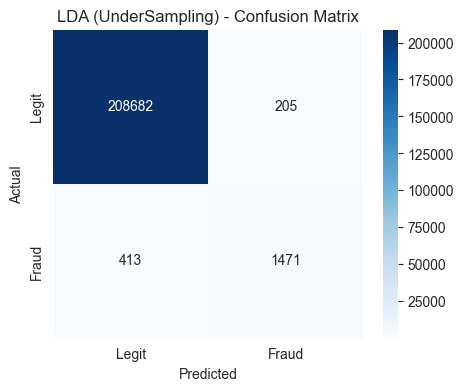

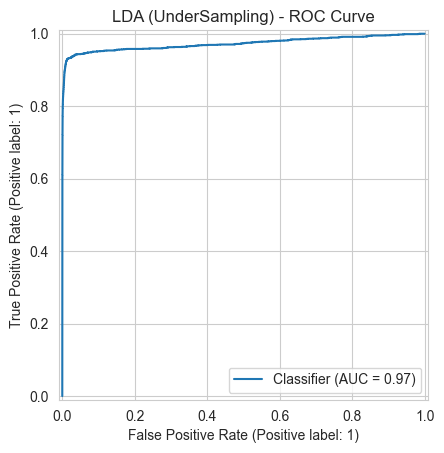

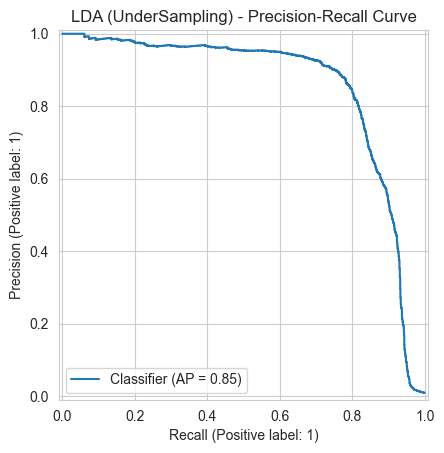

LightGBM
[LightGBM] [Info] Number of positive: 11008, number of negative: 55040
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004516 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4315
[LightGBM] [Info] Number of data points in the train set: 66048, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166667 -> initscore=-1.609438
[LightGBM] [Info] Start training from score -1.609438

Best threshold (by f1): 0.95
Precision: 0.934
Recall:    0.876
F1:        0.904

==================== LightGBM (UnderSampling) ====================
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    208887
       Fraud       0.93      0.88      0.90      1884

    accuracy                           1.00    210771
   macro avg       0.97      0.94      0.95    210771
weighted avg

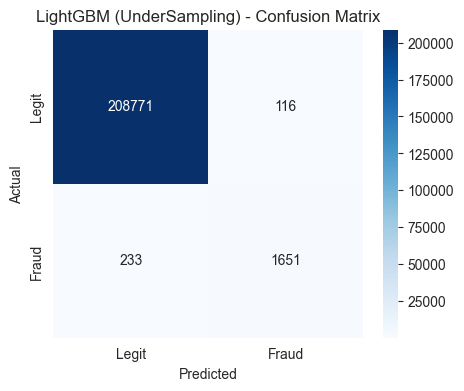

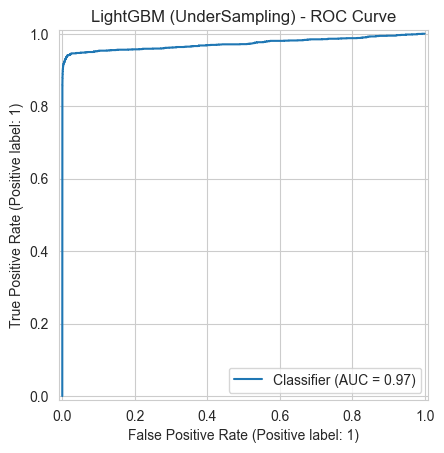

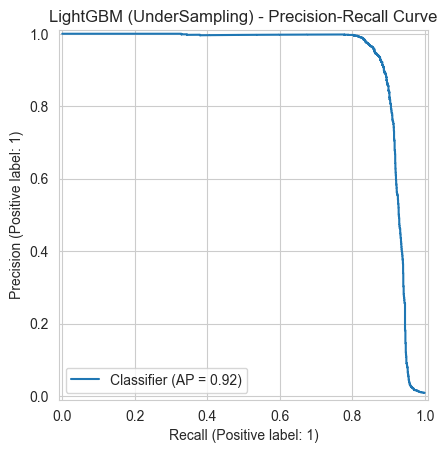

In [9]:
comparison_results = []

for name, model in models.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    undersample_pipe = Pipeline([
        ("preprocess", preprocess),

        ("undersample", RandomUnderSampler(
            sampling_strategy=0.2,
            random_state=42
        )),

        ("model", model)
    ])

    # -------------------
    # Train
    # -------------------
    undersample_pipe.fit(X_train, y_train)

    # -------------------
    # Holdout probabilities
    # -------------------
    y_prob = undersample_pipe.predict_proba(X_holdout)[:, 1]

    # -------------------
    # Best threshold
    # -------------------
    best_threshold, _ = evaluate.find_best_threshold(
        y_holdout,
        y_prob,
        metric="f1"
    )

    # -------------------
    # Predictions
    # -------------------
    y_pred = (y_prob >= best_threshold).astype(int)

    # -------------------
    # Evaluation
    # -------------------
    metrics = evaluate.evaluate_w_visualization(
        y_test=y_holdout,
        y_pred=y_pred,
        y_prob=y_prob,
        model_name=f"{name} (UnderSampling)"
    )

    # Store metrics
    metrics["Model"] = name
    metrics["Threshold"] = best_threshold

    comparison_results.append(metrics)

In [10]:
comparison_df = pd.DataFrame(comparison_results)

comparison_df = comparison_df[
    [
        "Model",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ]
]

comparison_df.sort_values("PR-AUC", ascending=False)

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
2,LightGBM,0.95,0.998344,0.934352,0.876327,0.904410,0.972689,0.922918
0,Logistic Regression,0.92,0.997258,0.881425,0.800955,0.839266,0.971903,0.875693
1,LDA,0.86,0.997068,0.877685,0.780786,0.826404,0.972782,0.854541


## Using Undersampling

In [11]:
# retrain
lgbm_model = models["LightGBM"]

final_pipe = Pipeline([
    ("preprocess", preprocess),

    ("undersample", RandomUnderSampler(
        sampling_strategy=0.2,
        random_state=42
    )),

    ("model", lgbm_model)   # your trained LightGBM estimator
])

final_pipe.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 11008, number of negative: 55040
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002464 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4315
[LightGBM] [Info] Number of data points in the train set: 66048, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166667 -> initscore=-1.609438
[LightGBM] [Info] Start training from score -1.609438


,steps,"[('preprocess', ...), ('undersample', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](26,)","['TRANSACTION_ID','CUSTOMER_ID','TERMINAL_ID',...,'ratio_to_lag3', 'is_test_tx_sequence','neigh_fraud_rate']"
n_features_in_,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [12]:
y_prob_oot = final_pipe.predict_proba(X_oot)[:, 1]

y_pred_oot = (y_prob_oot >= best_threshold).astype(int)


==================== LightGBM - OOT (Threshold=0.950) ====================
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    199661
       Fraud       0.95      0.88      0.91      1789

    accuracy                           1.00    201450
   macro avg       0.97      0.94      0.96    201450
weighted avg       1.00      1.00      1.00    201450

ROC-AUC:  0.9719
PR-AUC:   0.9263


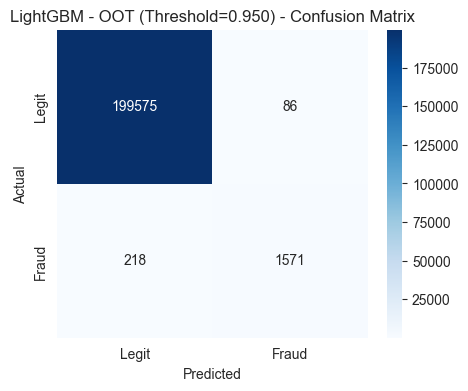

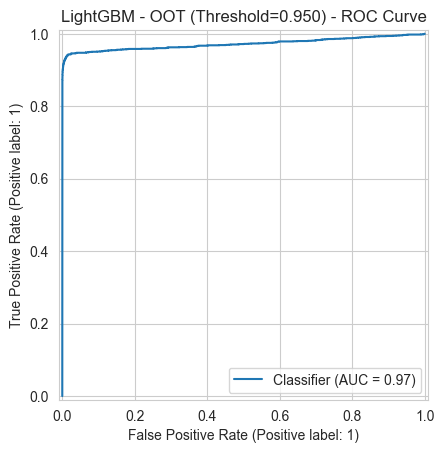

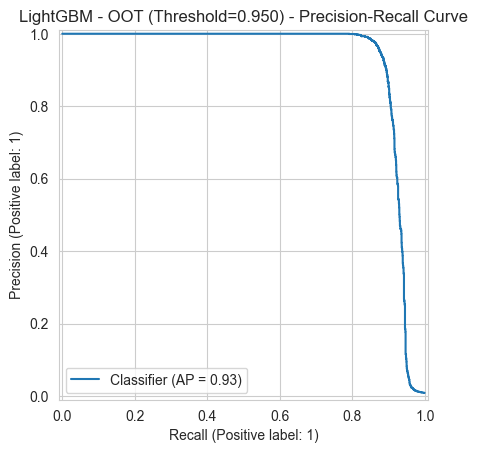

In [13]:
oot_results = evaluate.evaluate_w_visualization(
    y_test=y_oot,
    y_pred=y_pred_oot,
    y_prob=y_prob_oot,
    model_name=f"LightGBM - OOT (Threshold={best_threshold:.3f})"
)

## Edited Nearest Neighbor (ENN) undersampling

#### ENN Statistics

In [14]:
def analyze_enn_sampling(
    preprocess,
    X_train,
    y_train,
    n_neighbors=3,
    kind_sel="all",
):
    """
    Apply Edited Nearest Neighbours (ENN) and summarize
    how the dataset changes.

    Parameters
    ----------
    preprocess : sklearn transformer
        Preprocessing pipeline.
    X_train : pd.DataFrame
        Training features.
    y_train : pd.Series
        Training labels.
    n_neighbors : int
        Number of nearest neighbors.
    kind_sel : {"all", "mode"}
        ENN selection strategy.

    Returns
    -------
    X_resampled
    y_resampled
    summary_df
    """

    # -------------------------
    # Preprocess
    # -------------------------
    X_preprocessed = preprocess.fit_transform(X_train)

    # -------------------------
    # ENN
    # -------------------------
    enn = EditedNearestNeighbours(
        n_neighbors=n_neighbors,
        kind_sel=kind_sel
    )

    X_resampled, y_resampled = enn.fit_resample(
        X_preprocessed,
        y_train
    )

    # -------------------------
    # Statistics
    # -------------------------
    print(f"\n========== ENN ({kind_sel.upper()}) ==========")
    print(f"Original samples : {len(y_train):,}")
    print(f"After ENN        : {len(y_resampled):,}")
    print(f"Removed          : {len(y_train)-len(y_resampled):,}")

    before = y_train.value_counts().sort_index()
    after = y_resampled.value_counts().sort_index()

    summary = pd.DataFrame({
        "Before": before,
        "After ENN": after
    })

    summary.index = ["Normal", "Fraud"]

    summary["Removed"] = (
        summary["Before"] - summary["After ENN"]
    )

    summary["Removed (%)"] = (
        summary["Removed"] / summary["Before"] * 100
    ).round(2)

    summary["Class Ratio"] = (
        summary["After ENN"] / summary["After ENN"].sum()
    ).round(4)

    print(summary)

    return X_resampled, y_resampled, summary

In [15]:
X_enn_all, y_enn_all, summary_all = analyze_enn_sampling(
    preprocess=preprocess,
    X_train=X_train,
    y_train=y_train,
    n_neighbors=3,
    kind_sel="all"
)


========== ENN (ALL) ==========
Original samples : 1,341,934
After ENN        : 1,337,971
Removed          : 3,963
         Before  After ENN  Removed  Removed (%)  Class Ratio
Normal  1330926    1326963     3963          0.3       0.9918
Fraud     11008      11008        0          0.0       0.0082


In [16]:
X_enn_mode, y_enn_mode, summary_mode = analyze_enn_sampling(
    preprocess=preprocess,
    X_train=X_train,
    y_train=y_train,
    n_neighbors=3,
    kind_sel="mode"
)


========== ENN (MODE) ==========
Original samples : 1,341,934
After ENN        : 1,341,423
Removed          : 511
         Before  After ENN  Removed  Removed (%)  Class Ratio
Normal  1330926    1330415      511         0.04       0.9918
Fraud     11008      11008        0         0.00       0.0082


In [17]:
enn_pipe = Pipeline([
    ("preprocess", preprocess),

    ("enn", EditedNearestNeighbours(
        n_neighbors=3,
        kind_sel="all"
    )),

    ("model", LGBMClassifier(
        objective="binary",
        random_state=42
    ))
])

In [18]:
enn_pipe.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 11008, number of negative: 1326963
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4302
[LightGBM] [Info] Number of data points in the train set: 1337971, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.008227 -> initscore=-4.792026
[LightGBM] [Info] Start training from score -4.792026


,steps,"[('preprocess', ...), ('enn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](26,)","['TRANSACTION_ID','CUSTOMER_ID','TERMINAL_ID',...,'ratio_to_lag3', 'is_test_tx_sequence','neigh_fraud_rate']"
n_features_in_,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3



Best threshold (by f1): 0.99
Precision: 0.842
Recall:    0.817
F1:        0.829

==================== LightGBM + ENN ====================
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    208887
       Fraud       0.84      0.82      0.83      1884

    accuracy                           1.00    210771
   macro avg       0.92      0.91      0.91    210771
weighted avg       1.00      1.00      1.00    210771

ROC-AUC:  0.9520
PR-AUC:   0.7278


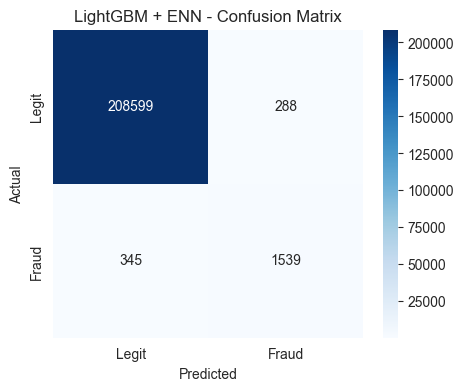

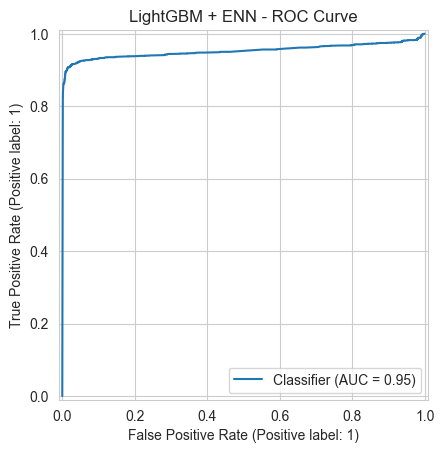

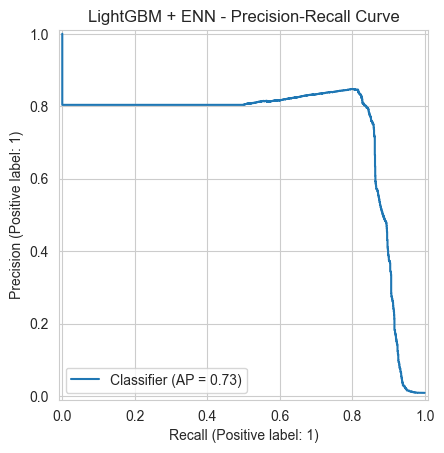

In [19]:
# Probabilities
y_prob = enn_pipe.predict_proba(X_holdout)[:, 1]

# Find best threshold
best_threshold, _ = evaluate.find_best_threshold(
    y_holdout,
    y_prob,
    metric="f1"
)

# Predictions
y_pred = (y_prob >= best_threshold).astype(int)

# Evaluation
enn_results = evaluate.evaluate_w_visualization(
    y_test=y_holdout,
    y_pred=y_pred,
    y_prob=y_prob,
    model_name="LightGBM + ENN"
)

### 06. Cross-Validation Evaluation

In [10]:
# Prepare LightGBM Piepline
lgbm_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),

        ("sampling", RandomUnderSampler(
            random_state=42
        )),

        ("model", LGBMClassifier(
            objective="binary",
            random_state=42
        ))
    ]
)

In [11]:
# hyperparameters grid
param_grid = {

    # undersampling ratio
    "sampling__sampling_strategy": [
        0.1,
        0.2,
        0.5
    ],

    # LightGBM params
    "model__n_estimators": [
        100,
        200,
        300
    ],

    "model__learning_rate": [
        0.01,
        0.05,
        0.1
    ],

    "model__num_leaves": [
        15,
        31,
        63
    ],

    "model__max_depth": [
        -1,
        5,
        10
    ],

    "model__min_child_samples": [
        20,
        50
    ]
}

In [ ]:
score_balanced_param_model = GridSearchCV(
    estimator=lgbm_pipe,
    param_grid=param_grid,
    scoring="average_precision",   # PR-AUC for fraud
    cv=3,
    n_jobs=-1,
    verbose=2
)

# train search
score_balanced_param_model.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 486 candidates, totalling 1458 fits


In [ ]:

print(score_balanced_param_model.best_params_)